# Prédiction des prix de l'immobilier en Californie

## 1. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tarfile
import urllib.request

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from pandas.plotting import scatter_matrix

## 2. Chargement des données

In [4]:
def load_housing():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
        housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing()
housing.head()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_26320\2830792432.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Exploration des données

Une observation représente un quartier. On cherche à comprendre :
1. Les corrélations entre variables pour identifier les plus explicatives
2. Les nouvelles variables à créer (feature engineering)

In [5]:
# Aperçu du nombre de lignes, types de colonnes et valeurs manquantes
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
# Vérification du nombre de catégories différentes dans ocean_proximity
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
# Statistiques descriptives
# Note : total_bedrooms a des NaN
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Visualisation géographique

<Axes: xlabel='longitude', ylabel='latitude'>

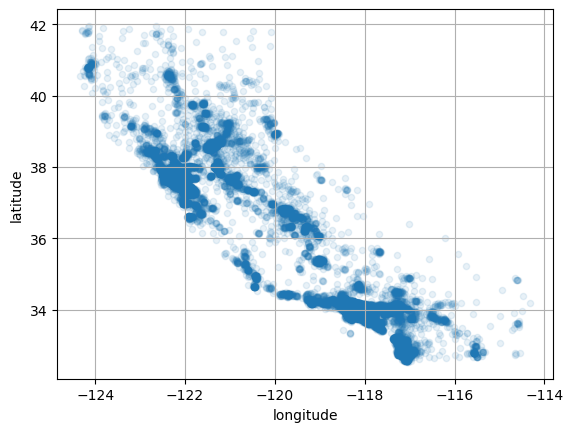

In [8]:
# Carte simple de la Californie
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1, grid=True)

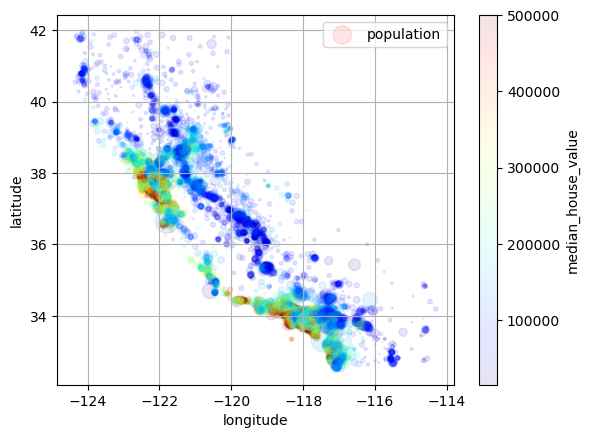

In [9]:
# Carte enrichie : taille = population, couleur = valeur médiane du logement
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.1,
    grid=True,
    s=housing["population"] / 100,
    label="population",
    c="median_house_value",
    cmap=plt.get_cmap("jet"),
    colorbar=True
)
plt.legend()
plt.show()

In [10]:
print(f"Population totale : {sum(housing['population']):,.0f}")

Population totale : 29,421,840


### Corrélations

In [11]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

## 4. Feature Engineering

In [12]:
# Création de nouvelles variables
housing["ratio_bedrooms"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["population_per_household"] = housing["population"] / housing["households"]

display(housing.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ratio_bedrooms,rooms_per_household,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0.146591,6.984127,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0.155797,6.238137,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0.129516,8.288136,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0.184458,5.817352,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0.172096,6.281853,2.181467


In [13]:
# Corrélations avec les nouvelles variables
corr_matrix_enhanced = housing.corr(numeric_only=True)
corr_matrix_enhanced["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
ratio_bedrooms             -0.255880
Name: median_house_value, dtype: float64

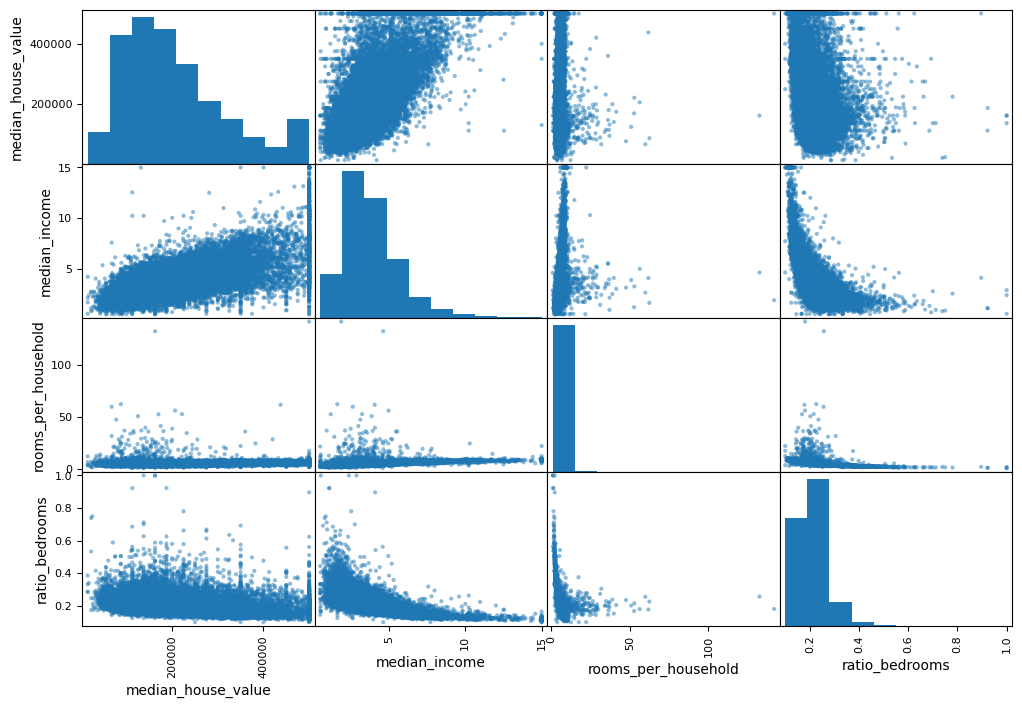

In [14]:
# Matrice de scatter plots pour les variables les plus corrélées
attributes = ["median_house_value", "median_income", "rooms_per_household", "ratio_bedrooms"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

## 5. Nettoyage des données

In [15]:
# Traitement des valeurs manquantes
# Options disponibles :
#   1. Supprimer la colonne : housing.drop("total_bedrooms", axis=1, inplace=True)
#   2. Supprimer les lignes : housing.dropna(subset=["total_bedrooms"], inplace=True)
#   3. Imputer avec la médiane (méthode recommandée)

housing["total_bedrooms"] = housing["total_bedrooms"].fillna(housing["total_bedrooms"].median())
housing["ratio_bedrooms"] = housing["ratio_bedrooms"].fillna(housing["ratio_bedrooms"].median())

# Vérification : aucune valeur manquante
housing.loc[housing.isnull().any(axis=1)].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ratio_bedrooms,rooms_per_household,population_per_household


In [16]:
# Imputation via SimpleImputer (méthode scikit-learn)
imputer = SimpleImputer(strategy="median")
housing_num = housing.select_dtypes(include=[np.number])

imputer.fit(housing_num)
X_imputed = imputer.transform(housing_num)

housing_num_clean = pd.DataFrame(X_imputed, columns=housing_num.columns, index=housing_num.index)
housing_num_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   total_rooms               20640 non-null  float64
 4   total_bedrooms            20640 non-null  float64
 5   population                20640 non-null  float64
 6   households                20640 non-null  float64
 7   median_income             20640 non-null  float64
 8   median_house_value        20640 non-null  float64
 9   ratio_bedrooms            20640 non-null  float64
 10  rooms_per_household       20640 non-null  float64
 11  population_per_household  20640 non-null  float64
dtypes: float64(12)
memory usage: 1.9 MB


### Encodage des variables catégorielles

In [17]:
encoder = LabelEncoder()
housing["ocean_proximity"] = encoder.fit_transform(housing["ocean_proximity"])
print("Catégories encodées :", list(enumerate(encoder.classes_)))
housing["ocean_proximity"].value_counts()

Catégories encodées : [(0, '<1H OCEAN'), (1, 'INLAND'), (2, 'ISLAND'), (3, 'NEAR BAY'), (4, 'NEAR OCEAN')]


ocean_proximity
0    9136
1    6551
4    2658
3    2290
2       5
Name: count, dtype: int64

## 6. Création des ensembles d'entraînement / validation / test

- **Entraînement** : 70 %
- **Validation** : 15 %
- **Test** : 15 %

In [18]:
y = housing["median_house_value"]
X = housing.drop(["median_house_value"], axis=1)

# Étape 1 : 70 % entraînement, 30 % temporaire
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Étape 2 : 15 % validation, 15 % test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Entraînement : {len(X_train)} lignes")
print(f"Validation   : {len(X_val)} lignes")
print(f"Test         : {len(X_test)} lignes")

Entraînement : 14448 lignes
Validation   : 3096 lignes
Test         : 3096 lignes


### Normalisation

- **StandardScaler** : recommandé dans la plupart des cas (moyenne=0, écart-type=1)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 7. Entraînement et évaluation des modèles

Métriques utilisées :
- **R²** : proportion de variance expliquée (entre 0 et 1, plus proche de 1 = meilleur)
- **RMSE** : erreur quadratique moyenne (plus bas = meilleur, pénalise les grandes erreurs)
- **MSE** : carré de RMSE

In [ ]:
def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} :")
    print(f"  MSE  = {mse:,.0f}")
    print(f"  RMSE = {rmse:,.0f}")
    print(f"  R²   = {r2:.4f}")
    print()

### Régression linéaire

In [21]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_val_scaled)
evaluate_model("Régression linéaire", y_val, y_pred_lr)

Régression linéaire :
  MSE  = 4,963,540,880
  RMSE = 70,452
  R²   = 0.6313



### Arbre de décision

In [22]:
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train_scaled, y_train)
y_pred_dt = model_dt.predict(X_val_scaled)
evaluate_model("Arbre de décision", y_val, y_pred_dt)

Arbre de décision :
  MSE  = 5,165,796,111
  RMSE = 71,873
  R²   = 0.6163



### Random Forest

In [23]:
# Plus le nombre d'arbres est élevé, plus le temps de calcul sera long
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_scaled, y_train)
y_pred_rf = model_rf.predict(X_val_scaled)
evaluate_model("Random Forest", y_val, y_pred_rf)

Random Forest :
  MSE  = 2,526,148,768
  RMSE = 50,261
  R²   = 0.8123



### Gradient Boosting

Combine plusieurs modèles faibles de façon séquentielle en corrigeant les erreurs du modèle précédent.

In [24]:
model_gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.2, random_state=42)
model_gb.fit(X_train_scaled, y_train)
y_pred_gb = model_gb.predict(X_val_scaled)
evaluate_model("Gradient Boosting", y_val, y_pred_gb)

Gradient Boosting :
  MSE  = 2,353,283,205
  RMSE = 48,511
  R²   = 0.8252



### Importance des variables (Gradient Boosting)

In [25]:
feature_names = X_train.columns.tolist()
importances = model_gb.feature_importances_

importance_df = pd.DataFrame({
    "variable": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Part d'explication de chaque variable dans le prix médian d'un logement :\n")
display(importance_df)

Part d'explication de chaque variable dans le prix médian d'un logement :



,variable,importance
7,median_income,0.544727
11,population_per_household,0.125691
8,ocean_proximity,0.090010
0,longitude,0.085780
1,latitude,0.071259
2,housing_median_age,0.035098
9,ratio_bedrooms,0.016600
10,rooms_per_household,0.016183
3,total_rooms,0.004399
4,total_bedrooms,0.003960


## 8. Évaluation finale sur le jeu de test

On utilise le meilleur modèle (Gradient Boosting) pour l'évaluation finale.

In [26]:
y_pred_final = model_gb.predict(X_test_scaled)
evaluate_model("Gradient Boosting (jeu de test)", y_test, y_pred_final)

Gradient Boosting (jeu de test) :
  MSE  = 2,320,426,948
  RMSE = 48,171
  R²   = 0.8351



## 9. Conclusion

Ce projet a permis de prédire le prix médian des logements en Californie à partir de données socio-économiques. Parmi les variables, le **revenu médian** est le facteur le plus déterminant (0.54).

Quatre modèles ont été comparés : la régression linéaire et l'arbre de décision atteignent un R² d'environ 0.63, tandis que le **Random Forest** (~0.81) et surtout le **Gradient Boosting** (~0.83) obtiennent de bien meilleures performances.

Le Gradient Boosting est retenu comme modèle final. Des améliorations sont envisageables : données plus récentes, validation croisée, ou ajout de variables contextuelles (écoles, transports).
